In [1]:
import os
import glob
import pandas as pd
import neurokit2 as nk
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Ustawienia wykresów
sns.set_theme(style="whitegrid")

print("Zaczynamy analizę...")

# 1. Wczytanie plików procedury dla 5 badanych
procedure_files = glob.glob("data/procedure/*.csv")
procedure_list = []

for file in procedure_files:
    # Wczytujemy pliki z rozdzielaczem ';' i radzimy sobie z 'None' tak jak na labach
    df = pd.read_csv(file, sep=';', na_values='None')
    df.columns = ['TIMESTAMP', 'ID', 'COND', 'IADS_ID', 'IAPS_ID', 'ANS_VALENCE', 'ANS_AROUSAL', 'ANS_TIME', 'EVENT']
    procedure_list.append(df)

# Łączymy w jedną tabelę
procedure_df = pd.concat(procedure_list, ignore_index=True)

# 2. Czyszczenie danych (odrzucamy braki i fazę treningową)
procedure_df = procedure_df[procedure_df['ANS_VALENCE'].notnull()]
procedure_df = procedure_df[procedure_df['COND'] != 'train']

# 3. Wyciągamy średnie pobudzenie (arousal) dla każdego z 5 graczy
# ANS_AROUSAL to wartość od 1 (niskie) do 9 (wysokie)
arousal_per_subject = procedure_df.groupby('ID')['ANS_AROUSAL'].mean().reset_index()
arousal_per_subject.rename(columns={'ANS_AROUSAL': 'Mean_Arousal'}, inplace=True)

print("Dane z procedury załadowane. Próba:", len(arousal_per_subject), "osób.")
display(arousal_per_subject)

Zaczynamy analizę...
Dane z procedury załadowane. Próba: 5 osób.


,ID,Mean_Arousal
0,103.0,5.284547
1,119.0,5.982761
2,120.0,5.919487
3,136.0,5.494718
4,141.0,6.085060


In [2]:
biosig_files = glob.glob("data/biosigs/*.csv")
eda_results = []

# Zakładamy próbkowanie 1000Hz (standard dla BITalino).
# Jeśli sygnał ma 100Hz, zmień sampling_rate na 100.
SAMPLING_RATE = 1000

for file in biosig_files:
    # Wyciągamy ID z nazwy pliku (np. "SUB001")
    subject_id = os.path.basename(file).split('-')[0]
    print(f"Przetwarzam sygnał dla: {subject_id}...")

    # Wczytanie pliku z sygnałami (zajmuje najwięcej czasu)
    # Parametr usecols pozwala wczytać TYLKO kolumnę z EDA, oszczędzając masę RAMu!
    # UWAGA: Upewnij się, jak dokładnie nazywa się kolumna EDA w pliku (często 'EDA' lub 'EDA (uS)')
    # Tutaj zakładam nazwę 'EDA'. Jeśli jest inna, zmień to słowo poniżej.
    try:
        df_bio = pd.read_csv(file, usecols=['EDA'])

        # Magia biblioteki NeuroKit2: filtrowanie i znajdowanie peaków EDA
        signals, info = nk.eda_process(df_bio['EDA'], sampling_rate=SAMPLING_RATE)

        # Zliczamy ilość wyłapanych reakcji stresowych (peaków)
        peaks_count = len(info['SCR_Peaks'])

        eda_results.append({'ID': subject_id, 'EDA_Peaks_Count': peaks_count})

        # Zwalniamy pamięć
        del df_bio
        del signals

    except ValueError as e:
        print(f"Błąd dla {subject_id}. Sprawdź, czy kolumna nazywa się dokładnie 'EDA' w pliku CSV.")

# Tworzymy dataframe z wynikami fizjologicznymi
eda_df = pd.DataFrame(eda_results)
print("Przetwarzanie EDA zakończone!")

Przetwarzam sygnał dla: SUB103...
Przetwarzam sygnał dla: SUB119...
Przetwarzam sygnał dla: SUB120...
Przetwarzam sygnał dla: SUB136...
Przetwarzam sygnał dla: SUB141...
Przetwarzanie EDA zakończone!


In [3]:
# --- NAPRAWA FORMATU ID ---
# 1. Zmieniamy float (np. 1.0) na int (1), a potem na zwykły tekst ("1")
arousal_per_subject['ID'] = arousal_per_subject['ID'].astype(int).astype(str)

# 2. Z tekstu np. "SUB001" usuwamy "SUB", zmieniamy na int (żeby obciąć zera z przodu do "1") i wracamy do tekstu ("1")
eda_df['ID'] = eda_df['ID'].str.replace('SUB', '', regex=False).astype(int).astype(str)
# ---------------------------

# Teraz łączymy bezpiecznie (oba ID to zwykły string z cyfrą)
final_data = pd.merge(arousal_per_subject, eda_df, on='ID')

from IPython.display import display # Import dodany na wszelki wypadek
display(final_data)

# Wyliczenie korelacji Spearmana
correlation, p_value = stats.spearmanr(final_data['Mean_Arousal'], final_data['EDA_Peaks_Count'])

print("-" * 40)
print("HIPOTEZA: Czy istnieje zależność między odczuwanym pobudzeniem a ilością peaków EDA?")
print(f"Współczynnik korelacji Spearmana: {correlation:.3f}")
print(f"P-value: {p_value:.3f}")

if p_value < 0.05:
    print("Wniosek: Wynik jest statystycznie istotny. Istnieje zależność!")
else:
    print("Wniosek: Brak istotności statystycznej (przy 5 osobach to całkowicie normalne).")
print("-" * 40)

,ID,Mean_Arousal,EDA_Peaks_Count
0,103,5.284547,66
1,119,5.982761,10
2,120,5.919487,20
3,136,5.494718,6
4,141,6.085060,20


----------------------------------------
HIPOTEZA: Czy istnieje zależność między odczuwanym pobudzeniem a ilością peaków EDA?
Współczynnik korelacji Spearmana: -0.205
P-value: 0.741
Wniosek: Brak istotności statystycznej (przy 5 osobach to całkowicie normalne).
----------------------------------------


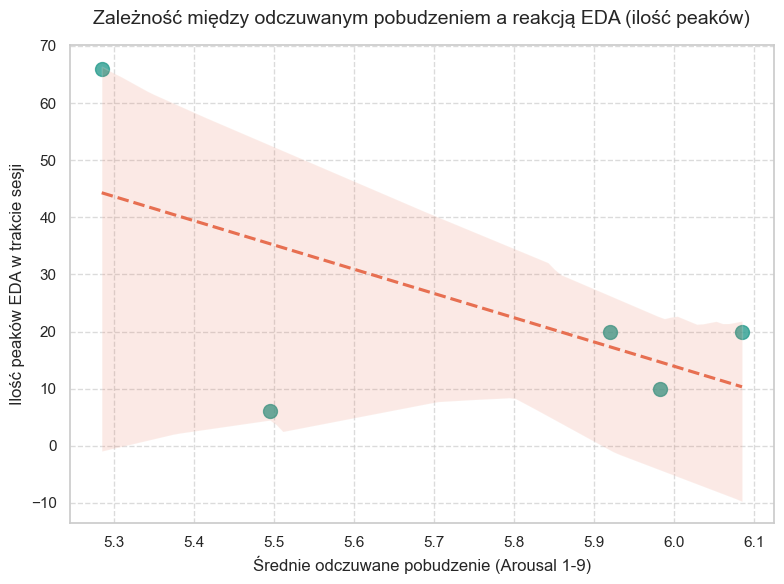

In [4]:
# Tworzymy elegancki wykres punktowy pokazujący naszą zależność
plt.figure(figsize=(8, 6))

# Regression plot - nakłada punkty i próbuje dopasować linię trendu
sns.regplot(
    data=final_data,
    x='Mean_Arousal',
    y='EDA_Peaks_Count',
    scatter_kws={'s': 100, 'color': '#2a9d8f'}, # stylizacja punktów
    line_kws={'color': '#e76f51', 'linestyle': '--'} # stylizacja linii trendu
)

plt.title('Zależność między odczuwanym pobudzeniem a reakcją EDA (ilość peaków)', fontsize=14, pad=15)
plt.xlabel('Średnie odczuwane pobudzenie (Arousal 1-9)', fontsize=12)
plt.ylabel('Ilość peaków EDA w trakcie sesji', fontsize=12)

# Poprawienie czytelności
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Wyświetlamy
plt.show()

In [5]:
print("--- MOJE ANKIETY ---")
print(arousal_per_subject.head())

print("\n--- MOJE SYGNAŁY ---")
print(eda_df.head())

print("\n--- POŁĄCZONA TABELA ---")
print(final_data)

--- MOJE ANKIETY ---
    ID  Mean_Arousal
0  103      5.284547
1  119      5.982761
2  120      5.919487
3  136      5.494718
4  141      6.085060

--- MOJE SYGNAŁY ---
    ID  EDA_Peaks_Count
0  103               66
1  119               10
2  120               20
3  136                6
4  141               20

--- POŁĄCZONA TABELA ---
    ID  Mean_Arousal  EDA_Peaks_Count
0  103      5.284547               66
1  119      5.982761               10
2  120      5.919487               20
3  136      5.494718                6
4  141      6.085060               20
